# **Spam Email Classification**

Spam email is a broad term used to describe unsolicited messages including: marketing, scams, or malware. These are often redundant, or could even potentially pose security risks to the recipient, and filtering is a common option used in removing spam from inboxes. 

This project will explore the historical data to develop a machine learning model that is capable of flagging spam emails based on a pre-defined set of attributes. This study will focus more on using reputable dataset and classification techniques to train a machine learning model rather than producing a deployable system that can be used in today's real-world environment.

This project uses the Spambase dataset from the UCI Machine Learning Repository.

**Citation**: <br>
Hopkins, M., Reeber, E., Forman, G., & Suermondt, J. (1999). <br>
Spambase [Dataset]. UCI Machine Learning Repository. <br>
https://archive.ics.uci.edu/dataset/94/spambase

**License**: CC BY 4.0

## **Table of Contents**

1. [Problem Statement](#1-problem-statement) <br>
&emsp; 1.1 [The Aim](#11---the-aim) <br>
&emsp; 1.2 [Objectives](#12---objectives) <br>
&emsp; 1.3 [Methodology](#13---methodology) <br>
&emsp; 1.4 [Scope Limitations](#14---scope--limitations) <br>
2. [Libraries](#2-libraries) <br>
3. [Data Pre-processing](#3-data-pre-processing) <br>
&emsp; 3.1 [Fields](#31---fields) <br>
&emsp; 3.2 [Cleaning the Dataset](#32---cleaning-the-dataset) <br>
&emsp; 3.3 [The Dataset](#33---dataset) <br>
&emsp;&emsp; 3.3.1 [Data Distribution](#331---data-distribution) <br>
&emsp;&emsp; 3.3.2 [Checking for Outliers](#332---checking-for-outliers) <br>
4. [Exploratory Data Analysis](#4-exploratory-data-analysis) <br>
&emsp; 4.1 [Linear Relationships](#41---linear-relationships) <br>
&emsp; 4.2 [Feature Importances](#42---random-forest---feature-importance) <br>
&emsp; 4.3 [Univariate Feature Selection](#43---univariate-feature-selection)

## 1. **Problem Statement**

Effective spam detection requires a clear understanding of the features that distinguish spam emails from legitimate messages. Through identification and analysis, the risk of misclassification can be reduced, therefore improving the model performance. This study uses the Spambase dataset from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/), a reputable public dataset used for email classification tasks. This dataset contains over 50 fields which can help contextualise the definition of a spam email. Furthermore, each record has been pre-assigned classification labels with approximately ~7% misclassification, making the labels reasonably reliable for modelling and evaluating classification.

### 1.1 - The Aim

***To develop a machine learning model capable of classifying spam and non-spam emails, achieving up to a 90% accuracy while maintaining a balanced performance accross precision and recall.***

### 1.2 - Objectives

**Main Objectives**
- Clean the dataset to improve the reliability of data used to train machine learning models, and document any changes.
    - Remove redundancy such as duplicates.
    - Conduct sense checks to ensure all fields are valid.
    - Fix any consistency issues within the data.
    - Verify the presence of missing or null values and handle if necessary.
    - Consider if data parsing would enrich the dataset.
    - Determine if outliers are present within the dataset and if so, handle it accordingly.
- Preliminary analysis to understand the shape of the data.
    - Check for class imbalances and address it if present.
    - Plot the distributions of features - Only highlight the most noteworthy features as there are a lot.
    - Assess feature distributions for skewness and consider transformations if needed.
    - Determine if the data needs to be normalised and handle it when applicable.
    - List out summary statistics.
- Conduct exploratory data analysis to evaluate the importance of each feature in classifying emails.
    - Correlation Matrix
    - Random Forest Feature Importances
    - Univariate Feature Selection (SelectKBest)
- Train classification models.
    - Split dataset into a training and testing set - Consider k-fold cross-validation for training.
    - Logistic Regression
    - Random Forest
    - Naive Bayes
- Evaluate the performance of each classification model.
    - Accuracy
    - Precision
    - Recall
    - F1 Score
    - Confusion Matrix
    - Establish a baseline model to provide a reference point for evaluating model performance.

**Additional Objectives**
- Conduct feature engineering to develop a ```Spam Score``` that measures the likelihood for spam flagging.
    - Create a calculated score based on available features.
    - Consider omitting features that have no impact on classification to reduce redundancy.
    - Apply weights according to feature importance.
- Evaluate the ```Spam Score``` to determine the viability of this calculated measure compared to standard machine learning models.
    - Train classification models using the ```Spam Score```.
    - Measure the performance of the models using accuracy score, F1 score, and precision and recall, then compare it against previous models.

### 1.3 - Methodology

**Excel** will be used to conduct the initial data inspection used to handle basic cleaning tasks, such as removing redundancy, and performing sense checks. Subsequently, **Python** will be utilised for more advanced data pre-processing and analysis, including outlier detection, normalisation, and data transformation.

Modelling of machine learning models and analysis will be done using Python libraries such as **pandas**, **sckit-learn**, **matplotlib**, and **seaborn**. From our defined list of objectives, classification techniques will be conducted, which will applied alongside feature analysis methods to evaluate the contribution of individual features to spam detection. These models will be trained using training and testing data which may undergo class rebalancing and k-fold cross-validation if necessary, to enhance the reliability of outcomes.

Multiple classification models will be trained to distinguish spam and non-spam emails. Each model's performance will then be evaluated using accuracy, precision, and recall techniques, with the intent of achieving a strong overall classification performance whilst minimising misclassification. If necessary, ensemble learning can be explored to further enhance model performance.

### 1.4 - Scope & Limitations

From the aim, two sets of objectives were derived. 
- A set of main objectives, representing core tasks required to complete the study.
- A set of additional objectives, representing optional tasks that enhance the depth and reliability of analysis.

These objectives were split into two parts for task prioritisation, ensuring that the essential components are completed within the alloted timeframe with room for development if time permits. The primary focus is ultimately to deliver a minimum viable product before extending the study.

This leads into the limitations:
- Time constraints.
- Limited domain knowledge.
- Limited technical knowledge.
- Use of a static dataset.

Of the limitations, the following were considered:

**Time constraints**
- Necessitates the prioritisation of core tasks over optional objectives.
- Limit the overall scope to ensure timely completion.
- Optional tasks should only be persued after core tasks have been achieved.

**Limited domain knowledge**
- Reduces the interpretability of this study for real-world relevance.
- Study should be treated as research rather than real-world application.

**Limited technical knowledge**
- Balance familiar modelling techniques (Random Forest, Logistic regression) and unfamiliar techniques (Naive Bayes).
- Encourages self-development and exploration, whilst maintaining a managable level of complexity.
- Reduces the amount of time spent learning new concepts and techniques.

**Use of a static dataset**
- The dataset is historical and may not reflect modern spam characteristics.
- Spam has becoming increasingly sophisticated, reducing the real-world revelance of this dataset.
- Project was framed as a preliminary study used for exploration of fundamentals.
- Project can be delved further for real-world application if updated with recent data, which can be compared to the findings of this study to determine changes over time.


## 2. **Libraries**

In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import zscore, pearsonr
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

import Utils.correlation_utils as corr_utils
import Utils.prep_utils as prep_utils
import Utils.classification_utils as class_utils
import Utils.evaluation_utils as eval_utils

## 3. **Data Pre-processing**

### 3.1 - Fields

**Field name rules:**
- Lower casing words.
- Underscores used for spaces.
- Field names with '_pct' are percentages.

**Field definitions:**
- *word_freq_(WORD)*
    - Frequency a word appears within an email.
    - Always calculated as a percentage of total words.
- *char_freq_(CHAR)*
    - Frequency a character appears within an email.
    - Always calculated as a percentage of total words.
- *captial_run_length_average*
    - Average length of sequences of consecutive capital letters.
- *captial_run_length_longest*
    - Maximum length of sequences of consecutive capital letters.
- *captial_run_length_total*
    - Total number of capital letters within an email.
- *is_spam*
    - 1 is spam.
    - 0 is ham (legitimate email).

Percent Encoded Charset:
- char_freq_**%3B** - **;**
- char_freq_**%28** - **(**
- char_freq_**%5B** - **[**
- char_freq_**%21** - **!**
- char_freq_**%24** - **$**
- char_freq_**%23** - **#**

### 3.2 - Cleaning the Dataset

**Dataset changes on Excel:**
- Original copy for rollback.
    - *What was done*: 
        - Made a backup of the original dataset.
        - Converted the dataset into a xlsx file.
    - **Version number**: v.1.0
- Feature renaming.
    - *What was done*: 
        - Added *'_pct'* at the end of field names that are calculated as a percentage.
        - Renamed *'class'* into *'is_spam'* for clarity of binary classifications.
    - **Version number**: v1.1

<br>

**Data Insights:**
- Dataset shape
    - **4601** rows.
    - Spread across **58** columns.
- **391** duplicates found on Excel 'remove duplicates' feature.
    - Kept in the dataset.
    - Avoids underrepresenting patterns of spam or non-spam email.
    - Maintains data distribution.
- Missing value checks.
    - No blanks detected using COUNTBLANK.
    - Zero values may represent absence of a feature rather than missing data.
- Sense checks.
    - Extreme values defined by human inference, using 20% as a threshold for relatively high values.
    - Extreme values found in the following fields:
        - *word_freq_3d_pct*
        - *word_freq_george_pct*
        - *word_freq_hp_pct*
        - *word_freq_project_pct*
        - *word_freq_re_pct*
        - *word_freq_edu_pct*
        - *char_freq_%21_pct*
        - *char_freq_%23_pct*
        - *capital_run_length_average*
        - *capital_run_length_longest*
        - *capital_run_length_total*
    - Further testing required will be conducted on Python using z-score or IQR to determine actual outliers based on mathematical testing.
- Value validation.
    - Data only contains numeric fields.
        - Performed a COUNT on each field expected to only contain numeric values.
        - Returned **4601** for each field (same number of rows), suggesting pure numeric values in each column.
    - No text fields therefore no spell checks or text formatting required.
    - Range checks.
        - Percentages do not exceed 100%.
        - Only two values are present for 'is_spam', 0 (**2788** values) or 1 (**1813** values).
            - Moderate class imbalance should be noted for models (**61%** non-spam to **39%** spam).
- Standardisation.
    - *'_pct'* was added to each percentage field for feature renaming.
    - No metric fields requiring standardisation at this stage.
- Data parsing.
    - Will be considered for optional creation of *'spam_score'*.

**Further data preprocessing will be conducted using Python for more thorough checks e.g.**
- Data scaling
- Outlier detection
- Train/test split
- Feature selection
- Distribution

### 3.3 - Dataset

In [32]:
data_Path = r'Dataset\spambase_v1.1_feature_renaming.csv'
data = pd.read_csv(data_Path)

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make_pct          4601 non-null   float64
 1   word_freq_address_pct       4601 non-null   float64
 2   word_freq_all_pct           4601 non-null   float64
 3   word_freq_3d_pct            4601 non-null   float64
 4   word_freq_our_pct           4601 non-null   float64
 5   word_freq_over_pct          4601 non-null   float64
 6   word_freq_remove_pct        4601 non-null   float64
 7   word_freq_internet_pct      4601 non-null   float64
 8   word_freq_order_pct         4601 non-null   float64
 9   word_freq_mail_pct          4601 non-null   float64
 10  word_freq_receive_pct       4601 non-null   float64
 11  word_freq_will_pct          4601 non-null   float64
 12  word_freq_people_pct        4601 non-null   float64
 13  word_freq_report_pct        4601 

#### 3.3.1 - Data Distribution

**Descriptive Statistics**

In [34]:
data.describe()

,word_freq_make_pct,word_freq_address_pct,word_freq_all_pct,word_freq_3d_pct,word_freq_our_pct,word_freq_over_pct,word_freq_remove_pct,word_freq_internet_pct,word_freq_order_pct,word_freq_mail_pct,...,char_freq_%3B_pct,char_freq_%28_pct,char_freq_%5B_pct,char_freq_%21_pct,char_freq_%24_pct,char_freq_%23_pct,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


**Class Balance**

In [35]:
#count_IsSpam_Spam = data[data['is_spam'] == 1].count()['is_spam']

count_IsSpam_Spam = (data['is_spam'] == 1).sum()
count_IsSpam_Ham = (data['is_spam'] == 0).sum()

print(f'Total spam emails: {count_IsSpam_Spam}')
print(f'Total ham emails: {count_IsSpam_Ham}')
#print(f'Total rows: {count_IsSpam_Spam + count_IsSpam_Ham}')

Total spam emails: 1813
Total ham emails: 2788


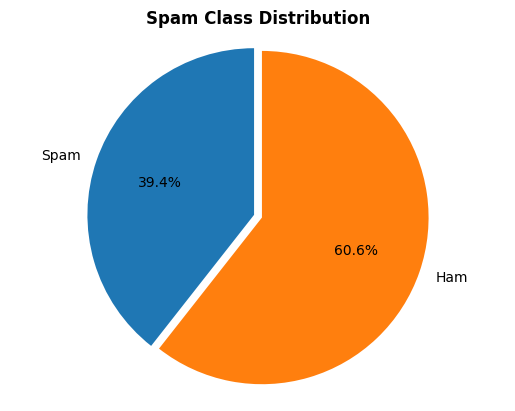

In [36]:
isSpam_classification_Y = [count_IsSpam_Spam, count_IsSpam_Ham]
isSpam_classification_Labels = ["Spam", "Ham"]

plt.pie(isSpam_classification_Y, labels = isSpam_classification_Labels, autopct='%1.1f%%',
        startangle=90, explode=[0.05, 0])

plt.title("Spam Class Distribution", fontdict={'weight':'bold'})
plt.axis('equal')

plt.show()

**Summary**
- Moderate class imbalance is exist between spam and ham classification.
- Uneven class distributions may lead to bias within machine learning models due to a underrepresented minority, which may decrease classification performance of spam classification.
- Imbalance is not severe enough to require immediate corrective measures, but should be considered during development of models and analysis.
- Methods of handling:
    - Random stratisfied sampling
    - Random undersampling
    - Random oversampling
    - Combination of multiple techniques
- When to consider uneven class distribution:
    - Train-test dataset splitting
    - Cross-validation
    - Classification model training
    - Evaluation of models

**Distribution**

In [37]:
#Parameters
dist_Labels_Word = ["word_freq_3d_pct", "word_freq_all_pct"]
dist_Labels_Char = ["char_freq_%21_pct", "char_freq_%23_pct"]
dist_Labels_Capital = ["capital_run_length_average", "capital_run_length_longest"]

isSpam_labels = ["Ham", "Spam"]

In [38]:
#Reusable Function to plot Log-Transformed KDE plots with multiple features being compared.
def log_kde_plots(features, legends, labels):

    fig, axes = plt.subplots(1, len(features), figsize=(12, 5))

    for i, feature in enumerate(features):                                              #Create a new plot for each feature

        for legend in legends.unique():                                                 #Create line graphs for each legend, in this case being spam or ham classification.
            subset = data[legends == legend][feature]                                   #Save data points of the feature of each legend.
            sns.kdeplot(np.log1p(subset), label=labels[legend], ax=axes[i])             #Plot the data points as a KDE using log-transformed values.

        axes[i].set_title(feature)
        axes[i].set_xlabel("Log-Transformed Values")
        axes[i].set_ylabel("Log-Transformed Density")
        axes[i].legend()
        
    plt.tight_layout()
    plt.show()

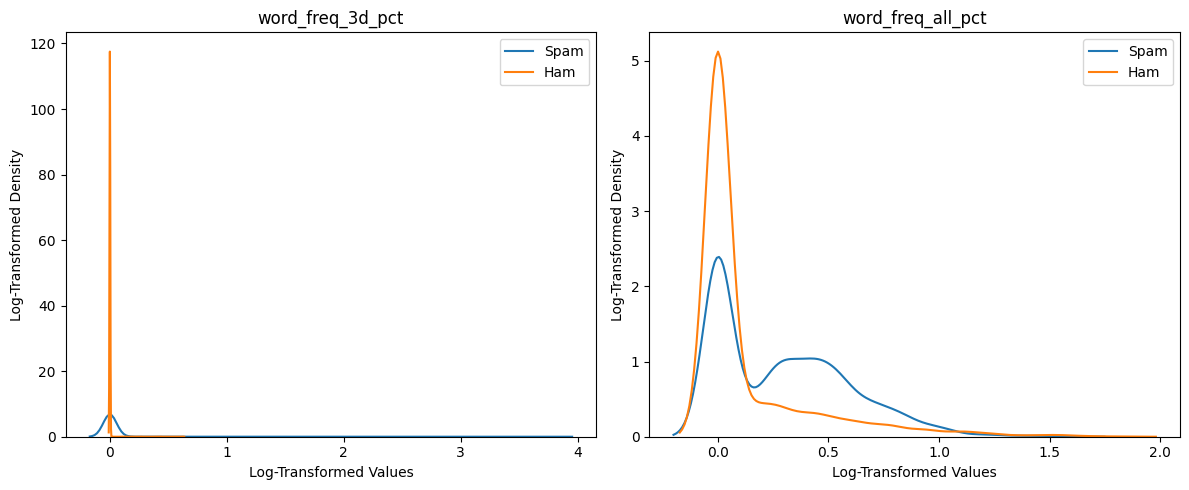

In [39]:
prep_utils.log_kde_plots(data, dist_Labels_Word, data['is_spam'], isSpam_labels)

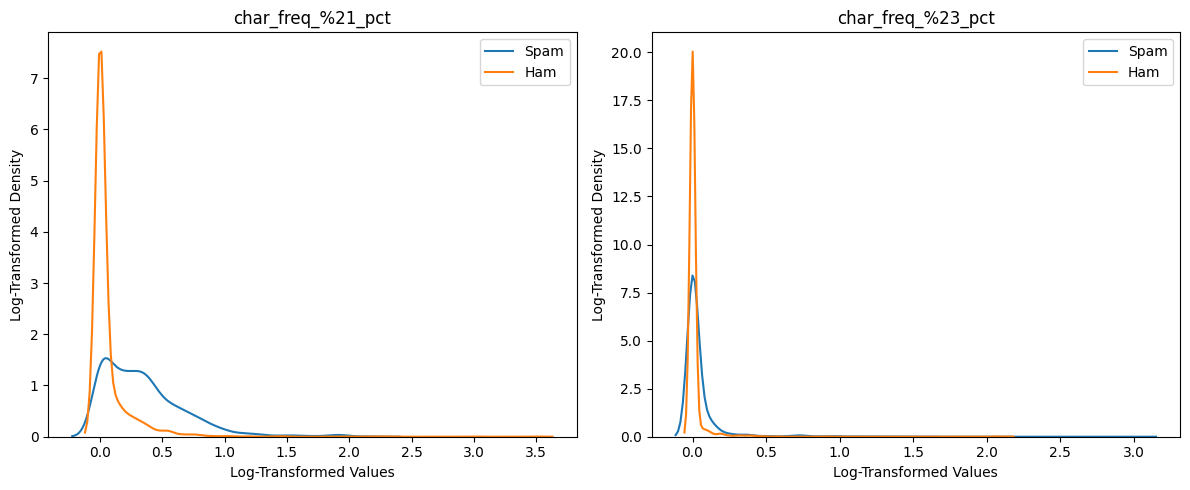

In [40]:
prep_utils.log_kde_plots(data, dist_Labels_Char, data['is_spam'], isSpam_labels)

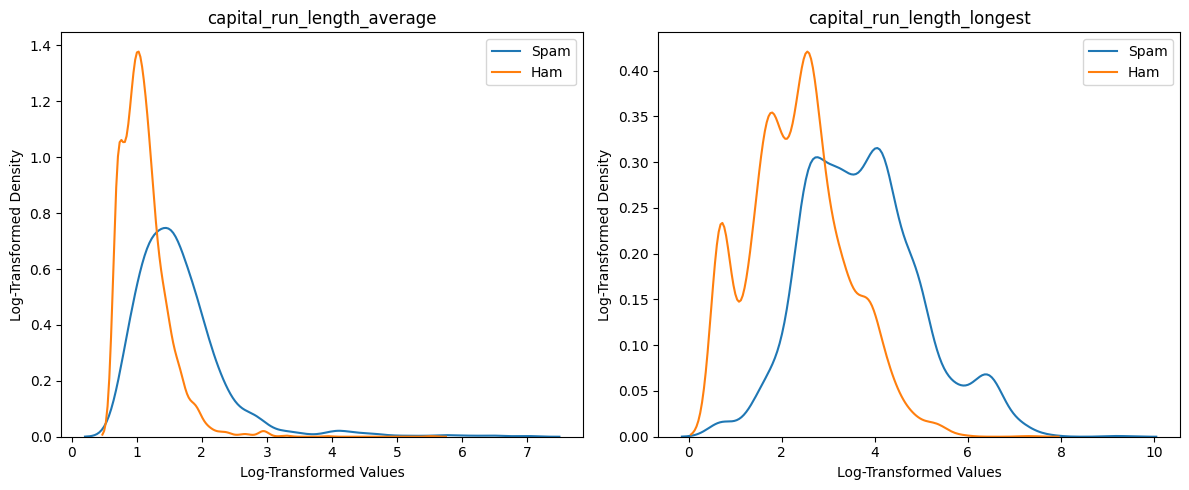

In [41]:
prep_utils.log_kde_plots(data, dist_Labels_Capital, data['is_spam'], isSpam_labels)

**Methodology**
- There were too many features to plot KDEs, therefore a sample of 6 features were taken, split evenly between the 3 primary categories of features:
    - Word frequency features.
    - Character frequency features.
    - Capitalisation features.
- Due to the presence of extreme values and heavily right-skewed distributions, log transformations using log1p() was applied for readability, whilst preserving relative differences between values.
- KDE plots were seperated into spam and ham classifications to compare the differences of distribution shapes.
- KDE plots were interpreted primarily based on distribution shape, including skewness, density concentration, and tail behaviour.

**Summary**
- None of the sampled features showed signs of normal distributions.
- Most sampled features demonstrated strong right skewness, with values concentrated near zero and long right tails extending towards larger values.
- Spam-related distributions generally displayed broader spread and heavier tails compared to ham distributions, suggesting spam emails are more likely to contain an unusually large feature values.
    - Pattern was particularly noticable in capitalisation and punctuation related features, where spam emails showed greater variability and more extreme observations.
- Ham email distributions were typically concentrated near zero, indiciating greater consistency and lower feature frequency across legitimate emails.
    - ```word_freq_3d_pct``` & ```char_freq_%23_pct``` shows particularly high density towards zero, suggesting that emails of this sample dataset commonly do not show these characteristics.
- These findings suggest that stylistic characteristics such as excessive punctuation, repeated symbols, or abnormal capitalisation patterns, may contribute towards distinguishing spam emails.

#### 3.3.2 - Checking for Outliers

**Using z-score**

In [42]:
#Parameters
outlier_Std = 3                         #Where 3 is default, any value exceeding 3 standard deviations will be classified as an outlier.
outlier_Feature_Threshold = 3           #Maximum number of features that can be flagged for outliers.
data_Columns = data.columns.values      #Columns in the dataset.

#print(len(data_Columns))

In [43]:
#Calculate the z-scores for each feature.
data_ZScore = pd.DataFrame(zscore(data[data_Columns], nan_policy='omit'), columns=data_Columns, index=data.index)

#Determine outliers based on defined standard deviation threshold.
zscore_Mask = abs(data_ZScore) > outlier_Std

#Count the number of features of a record flagged as an outlier. If the count exceeds 3, classify as an outlier.
zscore_Count = zscore_Mask.sum(axis=1)
zscore_Outliers = data[zscore_Count > outlier_Feature_Threshold]

#print(data_Outliers)
print(f'Number of standard deviations needed for feature to be flagged as an outlier: {outlier_Std}')
print(f'Number of features needed for row to be flagged as an outlier: >{outlier_Feature_Threshold}')
print(f'Number of detected outliers: {len(zscore_Outliers)}')

Number of standard deviations needed for feature to be flagged as an outlier: 3
Number of features needed for row to be flagged as an outlier: >3
Number of detected outliers: 125


**Using Interquartile Range (IQR)**

In [44]:
#Parameters
iqr_Q1 = data[data_Columns].quantile(0.25)
iqr_Q3 = data[data_Columns].quantile(0.75)
iqr_Range = iqr_Q3 - iqr_Q1

iqr_multiplier = 1.5          #Default multiplier value for IQR rule = 1.5

#print(iqr_Range)

In [45]:
iqr_Lower_Bounds = iqr_Q1 - (iqr_multiplier * iqr_Range)
iqr_Upper_Bounds = iqr_Q3 + (iqr_multiplier * iqr_Range)

#print(iqr_Lower_Bounds)
#print(iqr_Upper_Bounds)

#Flag values that greater than the upper or lower boundaries for IQR to be outliers.
iqr_Mask = (data[data_Columns] < iqr_Lower_Bounds) | (data[data_Columns] > iqr_Upper_Bounds)

#Count the number of features of a record flagged as an outlier. If the count exceeds 3, classify as an outlier.
iqr_Count = iqr_Mask.sum(axis=1)
iqr_Outliers = data[iqr_Count > outlier_Feature_Threshold]

print(f'Number of detected outliers: {len(iqr_Outliers)}')

Number of detected outliers: 2996


**Methodology**
- Two outlier detection methods were used to reduce reliance on a single statistical approach including:
    - z-Score analysis.
    - Interquartile range (IQR).
- z-Scores were conducted using a threshold of 3 standard deviations away from the mean, with values exceeding this range being flagged as an outlier.
- IQR analysis was conducted using a standard 1.5x IQR rule to identify observations outside expected quartile ranges. 
    - More than 3 features must demonstrate behaviours outside the IQR range before it can be flagged as showing signs of outlier behaviour.
- Multiple detection methods were utilised due to the highly skewed shape of the dataset which may impact findings.

**Summary**
- z-Score method produced 125 records flagged as potential outliers.
- IQR method flagged 2996 records containing outlier behaviour.
- Significantly larger number of IQR flagged outliers, suggest heavily skewed features with long tails.
- This behaviour is expected within the dataset due to:
    - High concentration of zero values.
    - Sparse feature occurence.
    - Extremely frequency spikes in a minority of emails.
- IQE method is sensitive to the dataset's distribution characteristics, causing a high number of records being flagged as exhibiting outlier behaviour.
- z-Scores producedmore conservative results, considered as more interpretable for identifying extreme observations within the dataset.
- Outliers were ultimately retained due to the shape of data, which may produce more meaningful spam characteristics rather than invalid observations or data entry errors.

## 4. **Exploratory Data Analysis**

### 4.1 - Linear Relationships

Creating a copy of the dataset without the classifier.

In [46]:
data_NoClass = data.copy()
data_NoClass = data_NoClass[data_NoClass.columns.drop('is_spam')]

#print(data_NoClass.columns.values)

corr_Data = data_NoClass.corr()                                                     #Calculate correlation between columns of the correlation matrix.

**Create a heatmap mask**

In [47]:
corr_pValues = corr_utils.Corr_Calculate_pValues(corr_Data, data_NoClass)                      #Assign a p-value to each correlation.

corr_Significance_Mask = corr_utils.Corr_Create_Significance_Mask(corr_pValues)                #Mask non-significant (greater than or equal to 0.05) correlations.
corr_Triangle_Mask = corr_utils.Corr_Create_Triangle_Mask(corr_Data)                           #Mask the upper triangle of the correlation matrix.

corr_Mask = corr_Triangle_Mask | corr_Significance_Mask                             #Return a combination of both masks.

**Complete Heatmap**

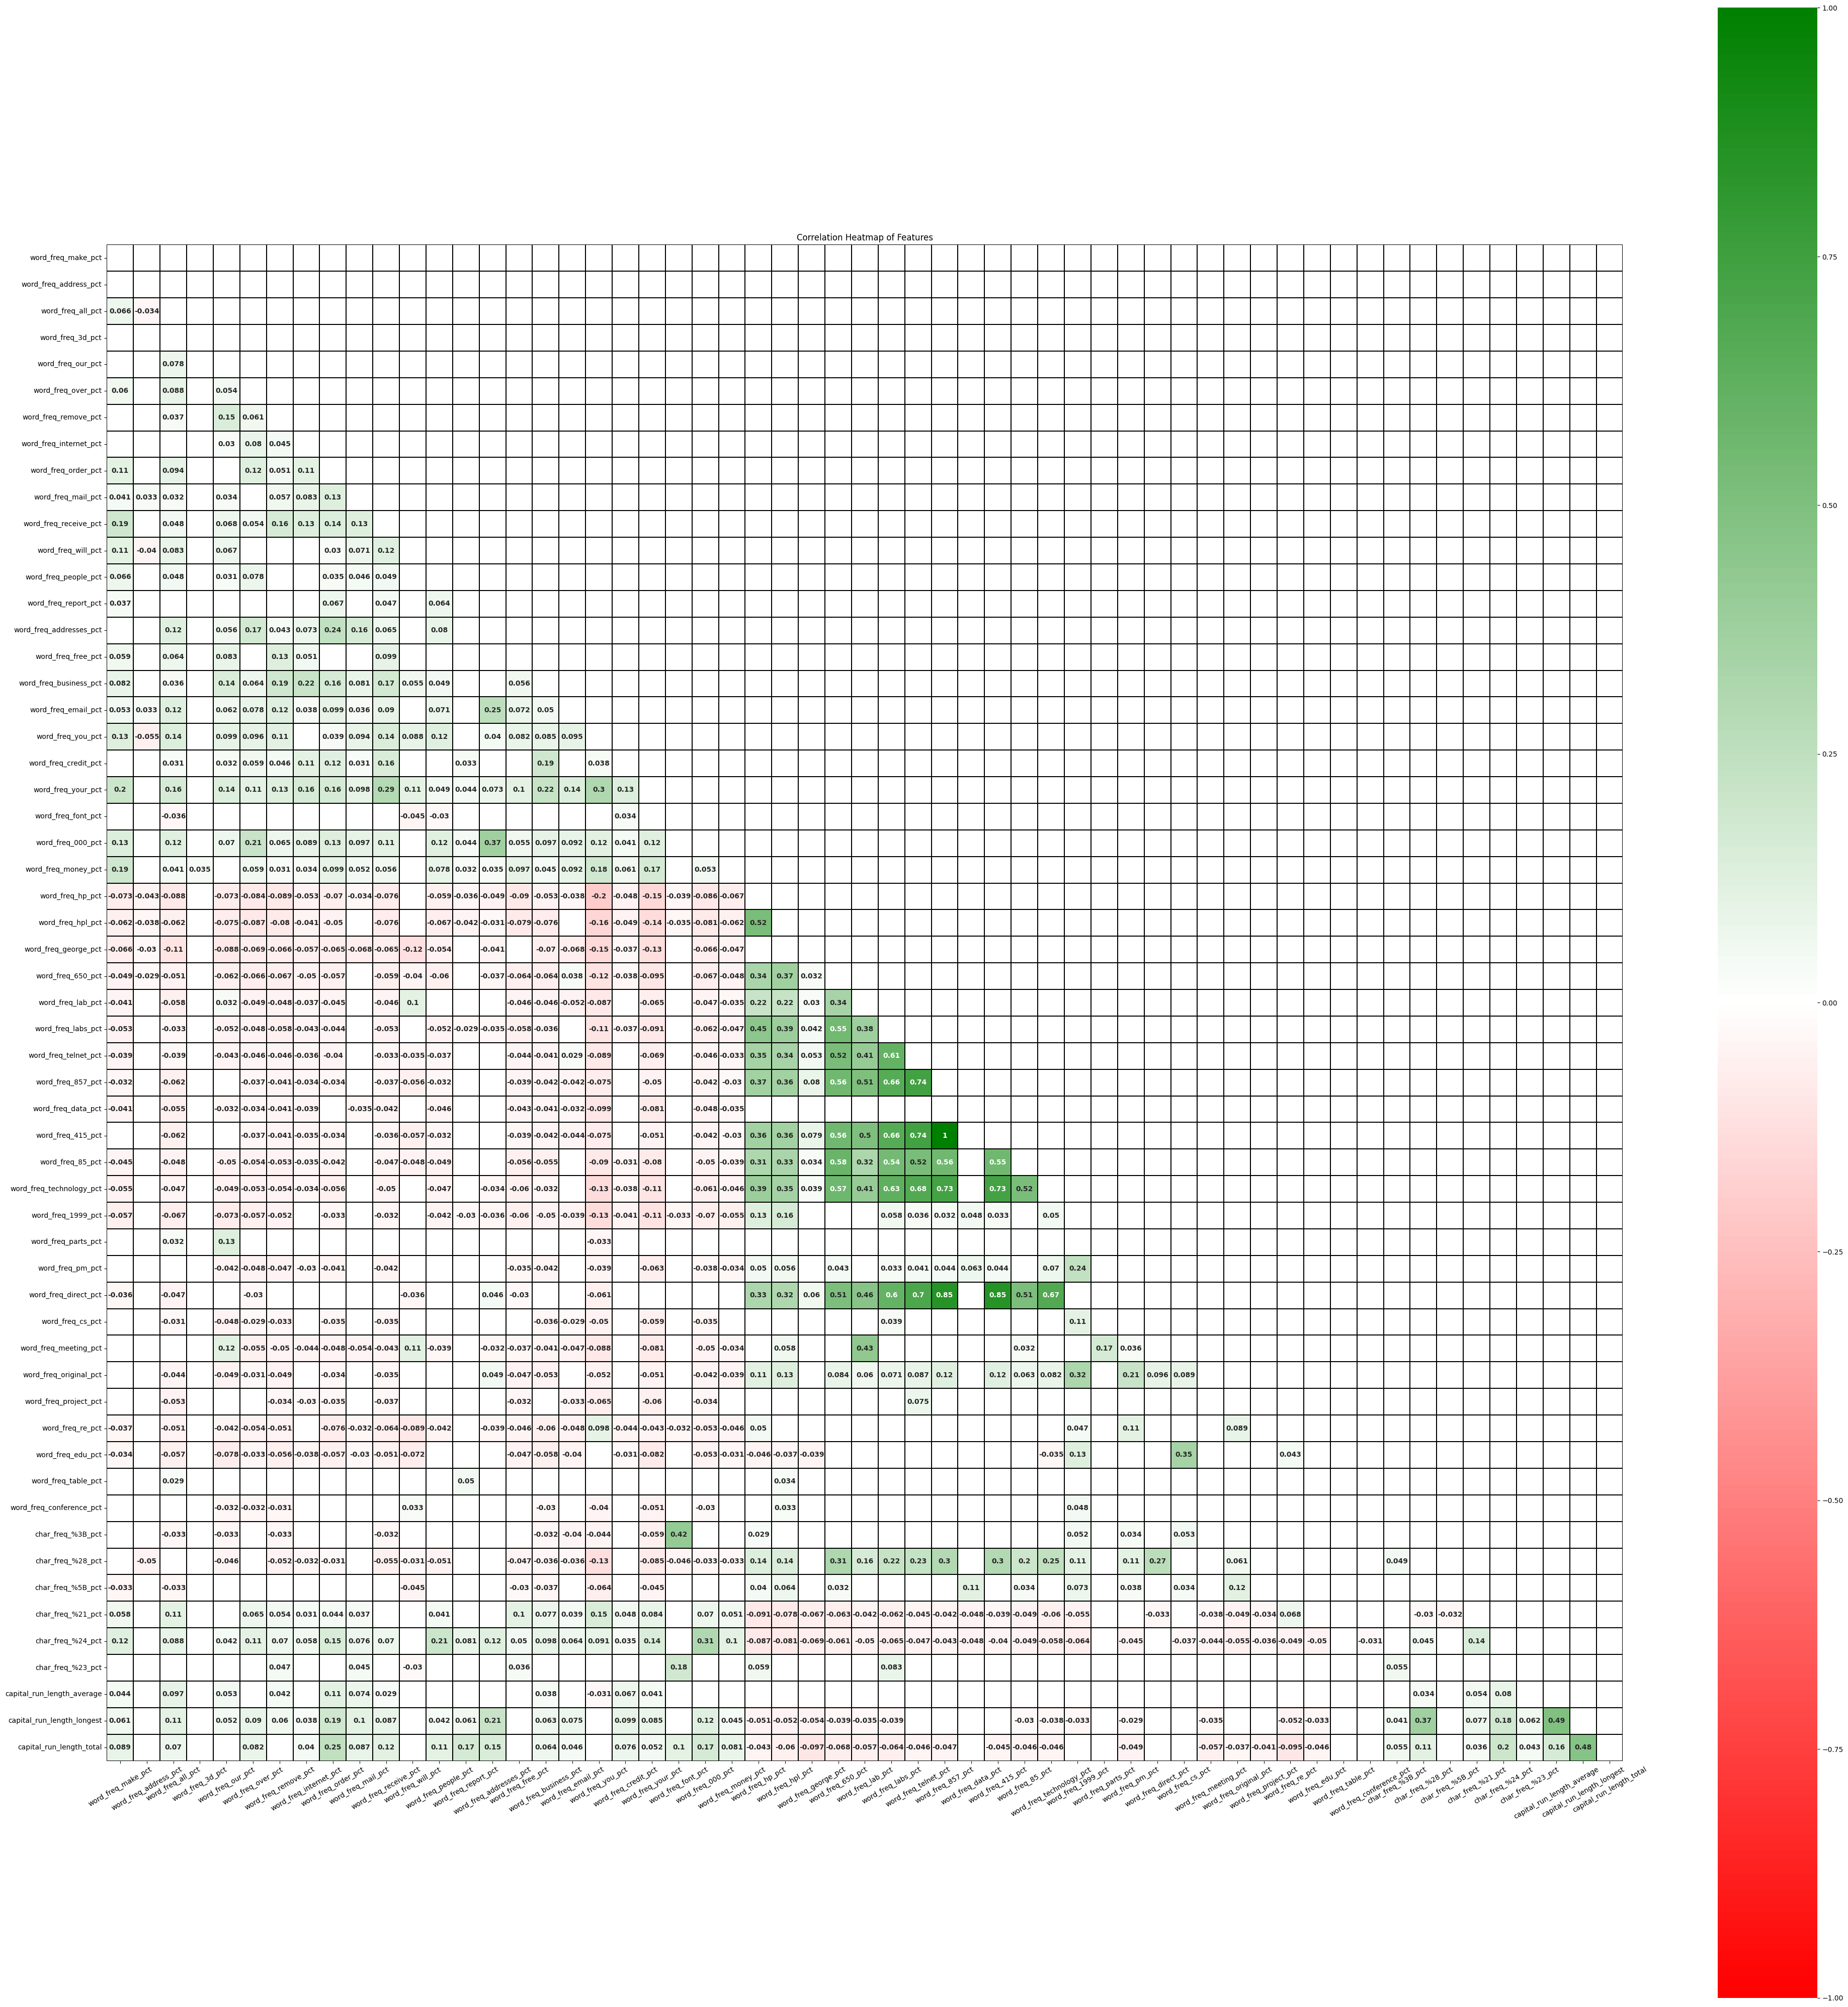

In [48]:
corr_utils.Plot_Correlation_Heatmap(corr_Data, corr_Mask, (40,40))

**Dimensionality Reduction**

Too many features are present which affect the overall readability of the correlation matrix, making it difficult to locate or identify the strongest contributing factors of spam and ham classification. 
<br>

Possible solutions:
- Masking - **Already done**
    - Concealing features or pairs that demonstrate neglible impact based on preliminary analysis.
    - Removing the upper or lower triangle of the correlation matrix which repeats the values of the other.
    - Eliminating correlations that are not statistically significant (p-values).
- Dimensionality Reduction
    - Removing features from the graph which creates noise in the visualisation.
    - Common methods include:
        - PCA
        - Factor Analysis
    - Both listed methods are time-consuming and difficult to interpret, therefore a third option will be chosen.
        - Selecting the **top 15** features based on features with the overall strongest relationships.
        - This provides an interpretable alternative that is quick and easy to produce.

**Define parameters for absolute correlations**

In [49]:
corr_Abs = corr_Data.abs()                                                              #Absolute correlations that ignore positive or negative correlations, focusing only on the difference from 0.
corr_Abs_Masked = corr_Abs.mask(corr_Mask)                                              #Conceal correlations that aren't statistically significant with NaN.

#print(corr_Abs_Masked)

**Sort and filter to top 15**

In [50]:
corr_Feature_Scores = corr_Abs_Masked.sum(axis=1).sort_values(ascending=False)           #Aggregate matrix by totals then sort it.
#print(corr_Feature_Scores)
corr_Top15_Features = corr_Feature_Scores.head(15).index.to_list()                       #Select the top 15 largest feature scores as a list.
#print(corr_Top15_Features)

corr_Top15_Data = data_NoClass[corr_Top15_Features].corr()                               #Produce correlation value for feature pairs from the top 15 list.
#print(corr_Top15_Data)

**Creating a new mask**

In [51]:
corr_Top15_Triangle_Mask = corr_utils.Corr_Create_Triangle_Mask(corr_Top15_Data)

corr_Top15_pValues = corr_utils.Corr_Calculate_pValues(corr_Top15_Data, corr_Abs[corr_Top15_Features])
corr_Top15_Significance_Mask = corr_utils.Corr_Create_Significance_Mask(corr_Top15_pValues, 0.05)

corr_Top15_Mask = corr_Top15_Triangle_Mask | corr_Top15_Significance_Mask

**Reduced Heatmap**

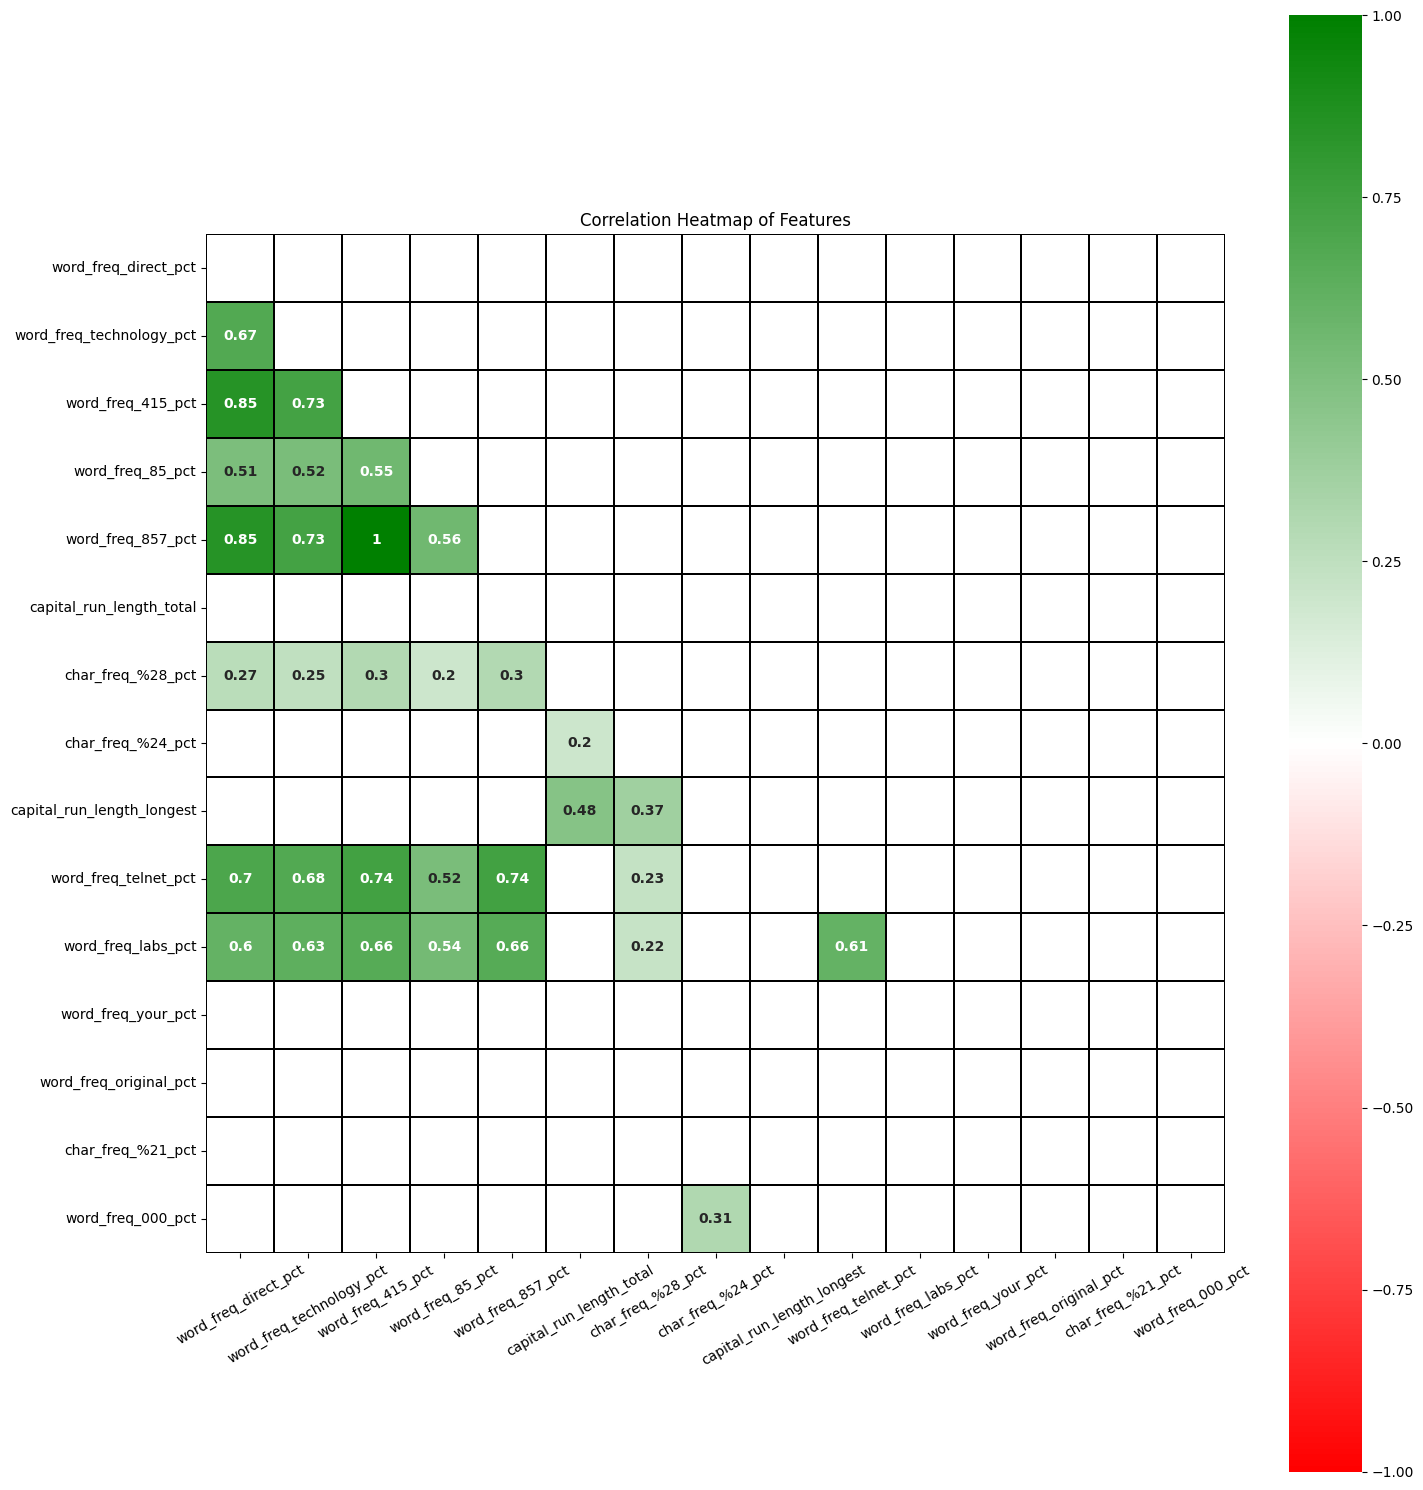

In [52]:
corr_utils.Plot_Correlation_Heatmap(corr_Top15_Data, corr_Top15_Mask)

**Summary:**
- Near perfect correlation between ```word_freq_857_pct``` and ```word_freq_415_pct``` suggesting they almost often appear together.
    - Could mean they share the same contextual use case.
    - May originate from the same source such as identifiers.
- Clusters are present between technical words and numerical values, namely the following.
    - word_freq_direct_pct
    - word_freq_technology_pct
    - word_freq_415_pct
    - word_freq_857_pct
    - word_freq_telnet_pct
    - word_freq_labs_pct
- Correlation range between the clusters is ~0.60 - 0.85.
    - Possible association between features for networking or IT related terms.
- Character based features have shown significant but weak linear relationships with other features.
    - Averging around ~0.2 - 0.3 correlation.
    - May suggest usage of punctuation increase alongside technical/numeric terms.
- Difficult to determine whether these relationships can be used to define spam or ham emails, as both are factored in the current dataset
    - Can be solved by seperately plotting a correlation heatmap for a subset of data exclusively containing spam emails, or vice versa.

**Split the dataset into classification subsets**

In [53]:
data_Spam = data[data['is_spam'] == 1]
data_Ham = data[data['is_spam'] == 0]

corr_Spam = data_Spam[corr_Top15_Features].corr()
corr_Ham = data_Ham[corr_Top15_Features].corr()

**Spam Emails**

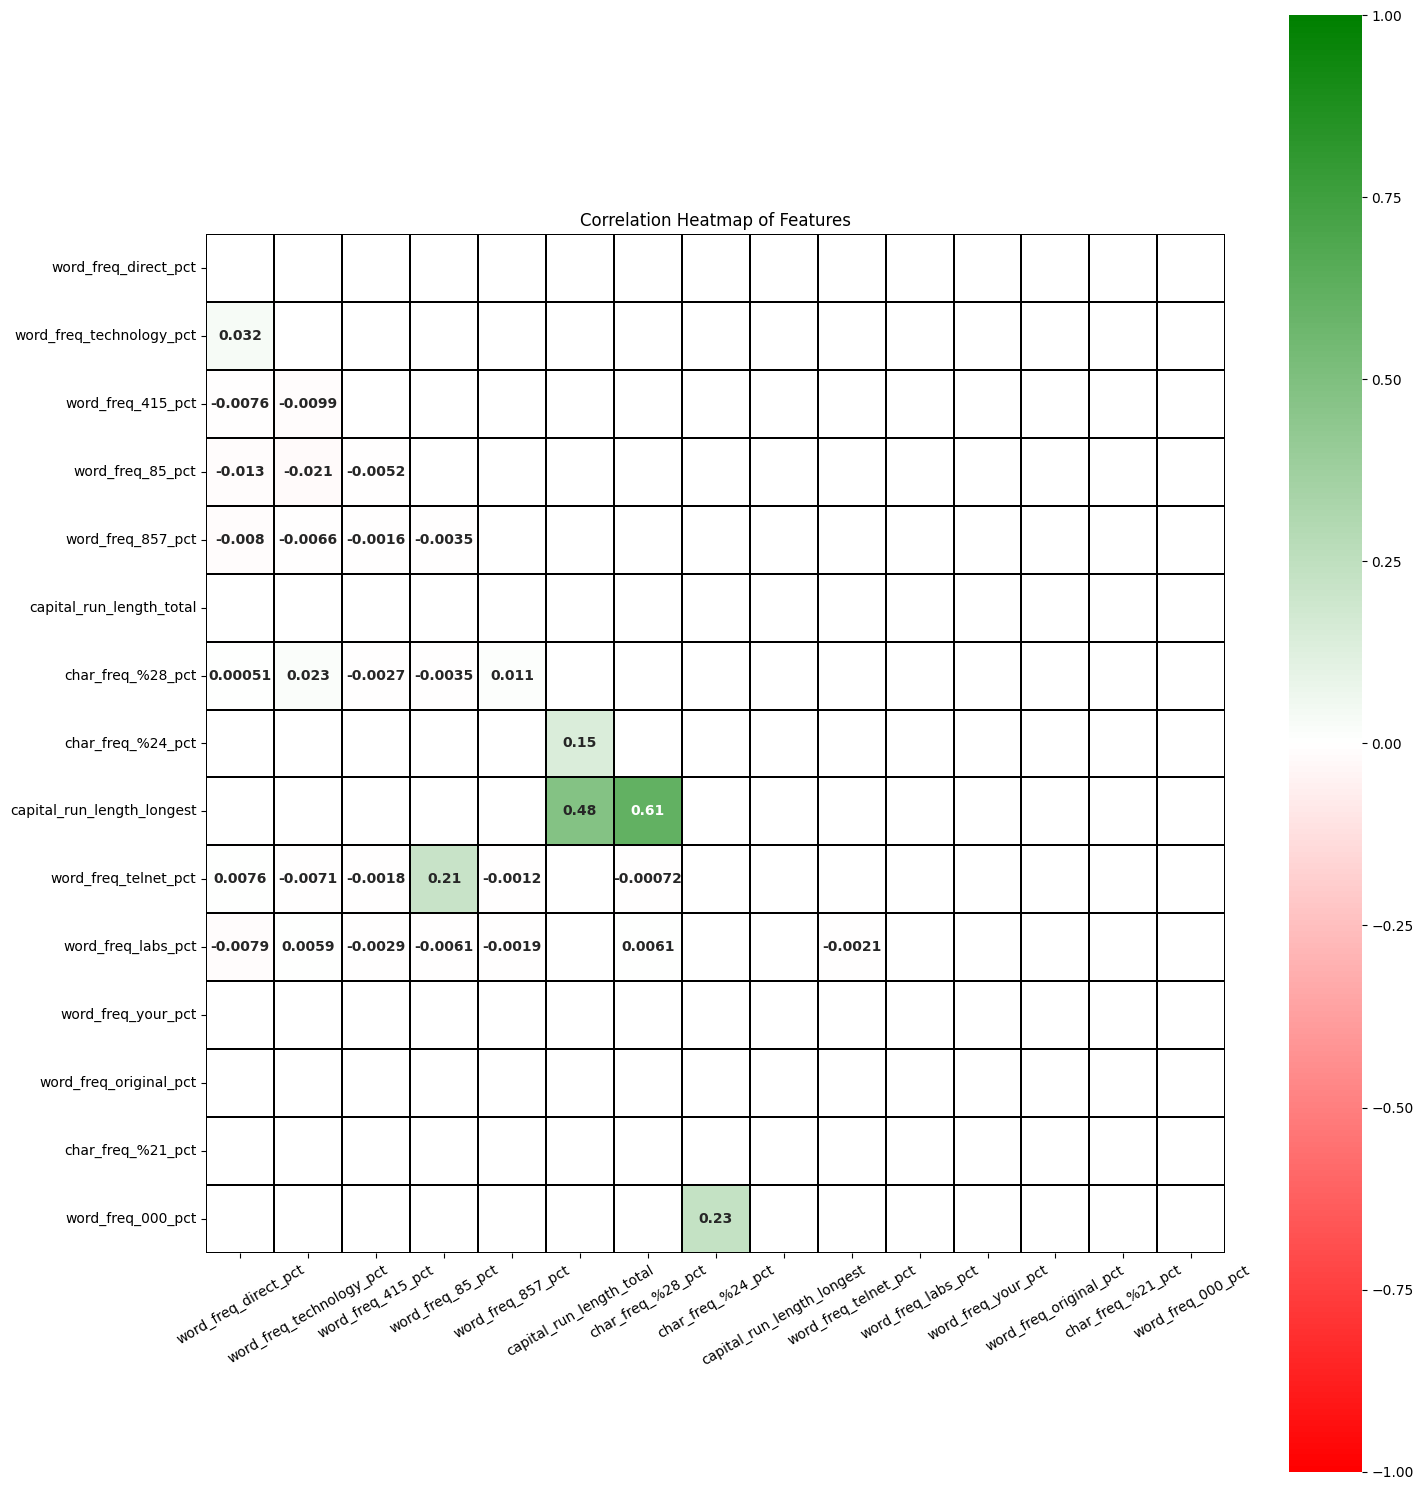

In [54]:
corr_utils.Plot_Correlation_Heatmap(corr_Spam, corr_Top15_Mask)

**Ham Emails**

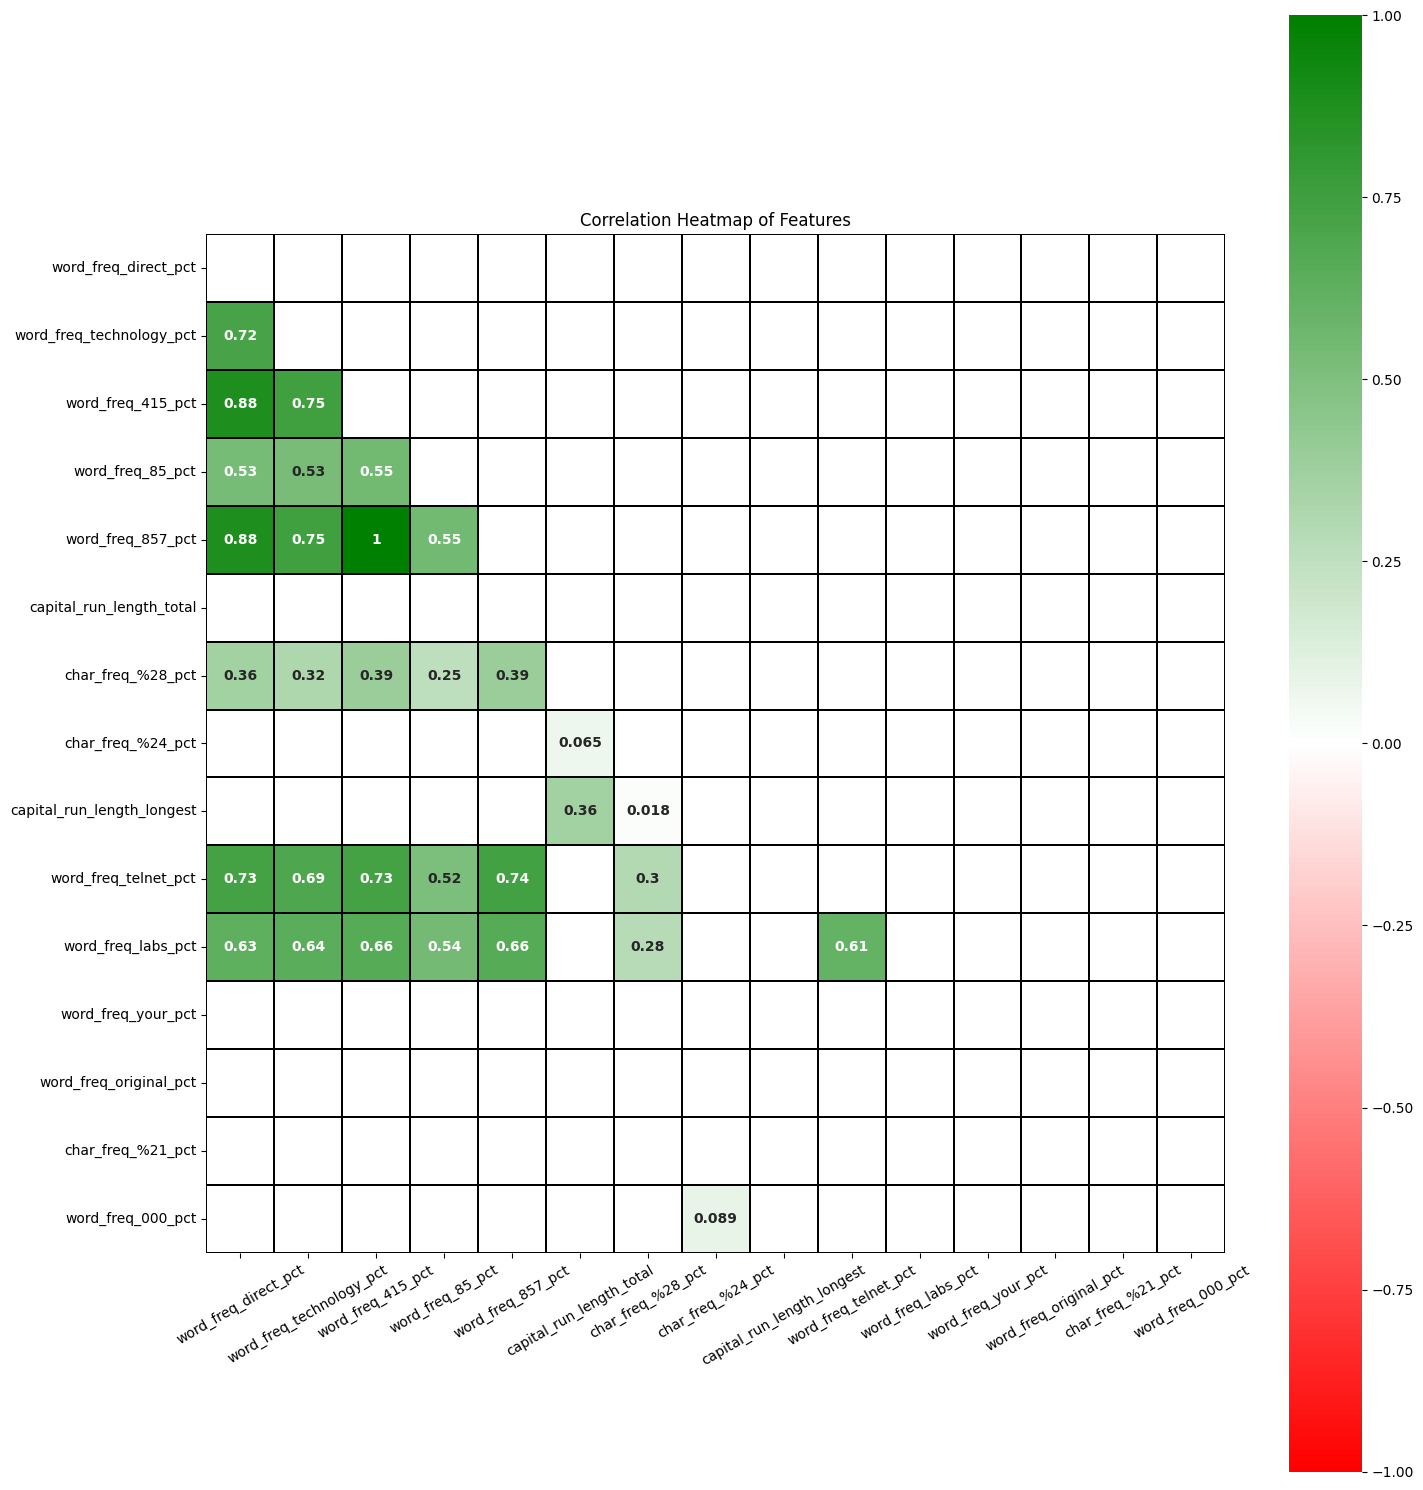

In [55]:
corr_utils.Plot_Correlation_Heatmap(corr_Ham, corr_Top15_Mask)

**Summary:**
- Ham emails demonstrate substantially stronger linear relationships between features than Spam.
    - Implies legitimate emails typically contain a structure or pattern that helps with identification.
    - Based on features with linear relationships, these patterns likely involve niche or technical terminology often used in association.
- Spam emails demonstrate weaker feature-to-feature correlatins.
    - Implies less consistent email structure.
    - Harder to identify spam emails relying solely on linear relationships.
- A moderate correlation exists within spam emails between capital letter usage, and special characters (%28).
    - Suggests exagerated or strong emphasis is more characteristic of certain spam email behaviour.
    - Theory should be explored further later.

### 4.2 - Random Forest - Feature Importance

**Normalising class imbalance w/ random undersampling**

Rescaling a class by randomly sampling emails based on the smallest class.

In [56]:
print(f"Number of spam emails: {data_Spam['is_spam'].count()}")
print(f"Number of ham emails: {data_Ham['is_spam'].count()}")

class_Sample_Size = data_Spam['is_spam'].count()
#print(class_Sample_Size)

Number of spam emails: 1813
Number of ham emails: 2788


There are less spam emails than ham, therefore ham emails will be randomly resampled based on the number of spam emails to balance out the two classes.

In [57]:
resample_Ham_Emails = resample(data_Ham, replace=False, n_samples=class_Sample_Size, random_state=1)
print(f"Number of ham emails: {resample_Ham_Emails['is_spam'].count()}")

Number of ham emails: 1813


In [58]:
data_Balanced = pd.concat([resample_Ham_Emails, data_Spam])
data_Balanced = data_Balanced.sample(frac=1, random_state=1).reset_index(drop=True)         #Reshuffle the data to reduce potential bias.

print(f"Balanced data rows: {data_Balanced.shape[0]}, Columns: {data_Balanced.shape[1]}")

model_Data_X =  data_Balanced[data_NoClass.columns]
model_Data_Y = data_Balanced['is_spam']

Balanced data rows: 3626, Columns: 58


**Visual model**

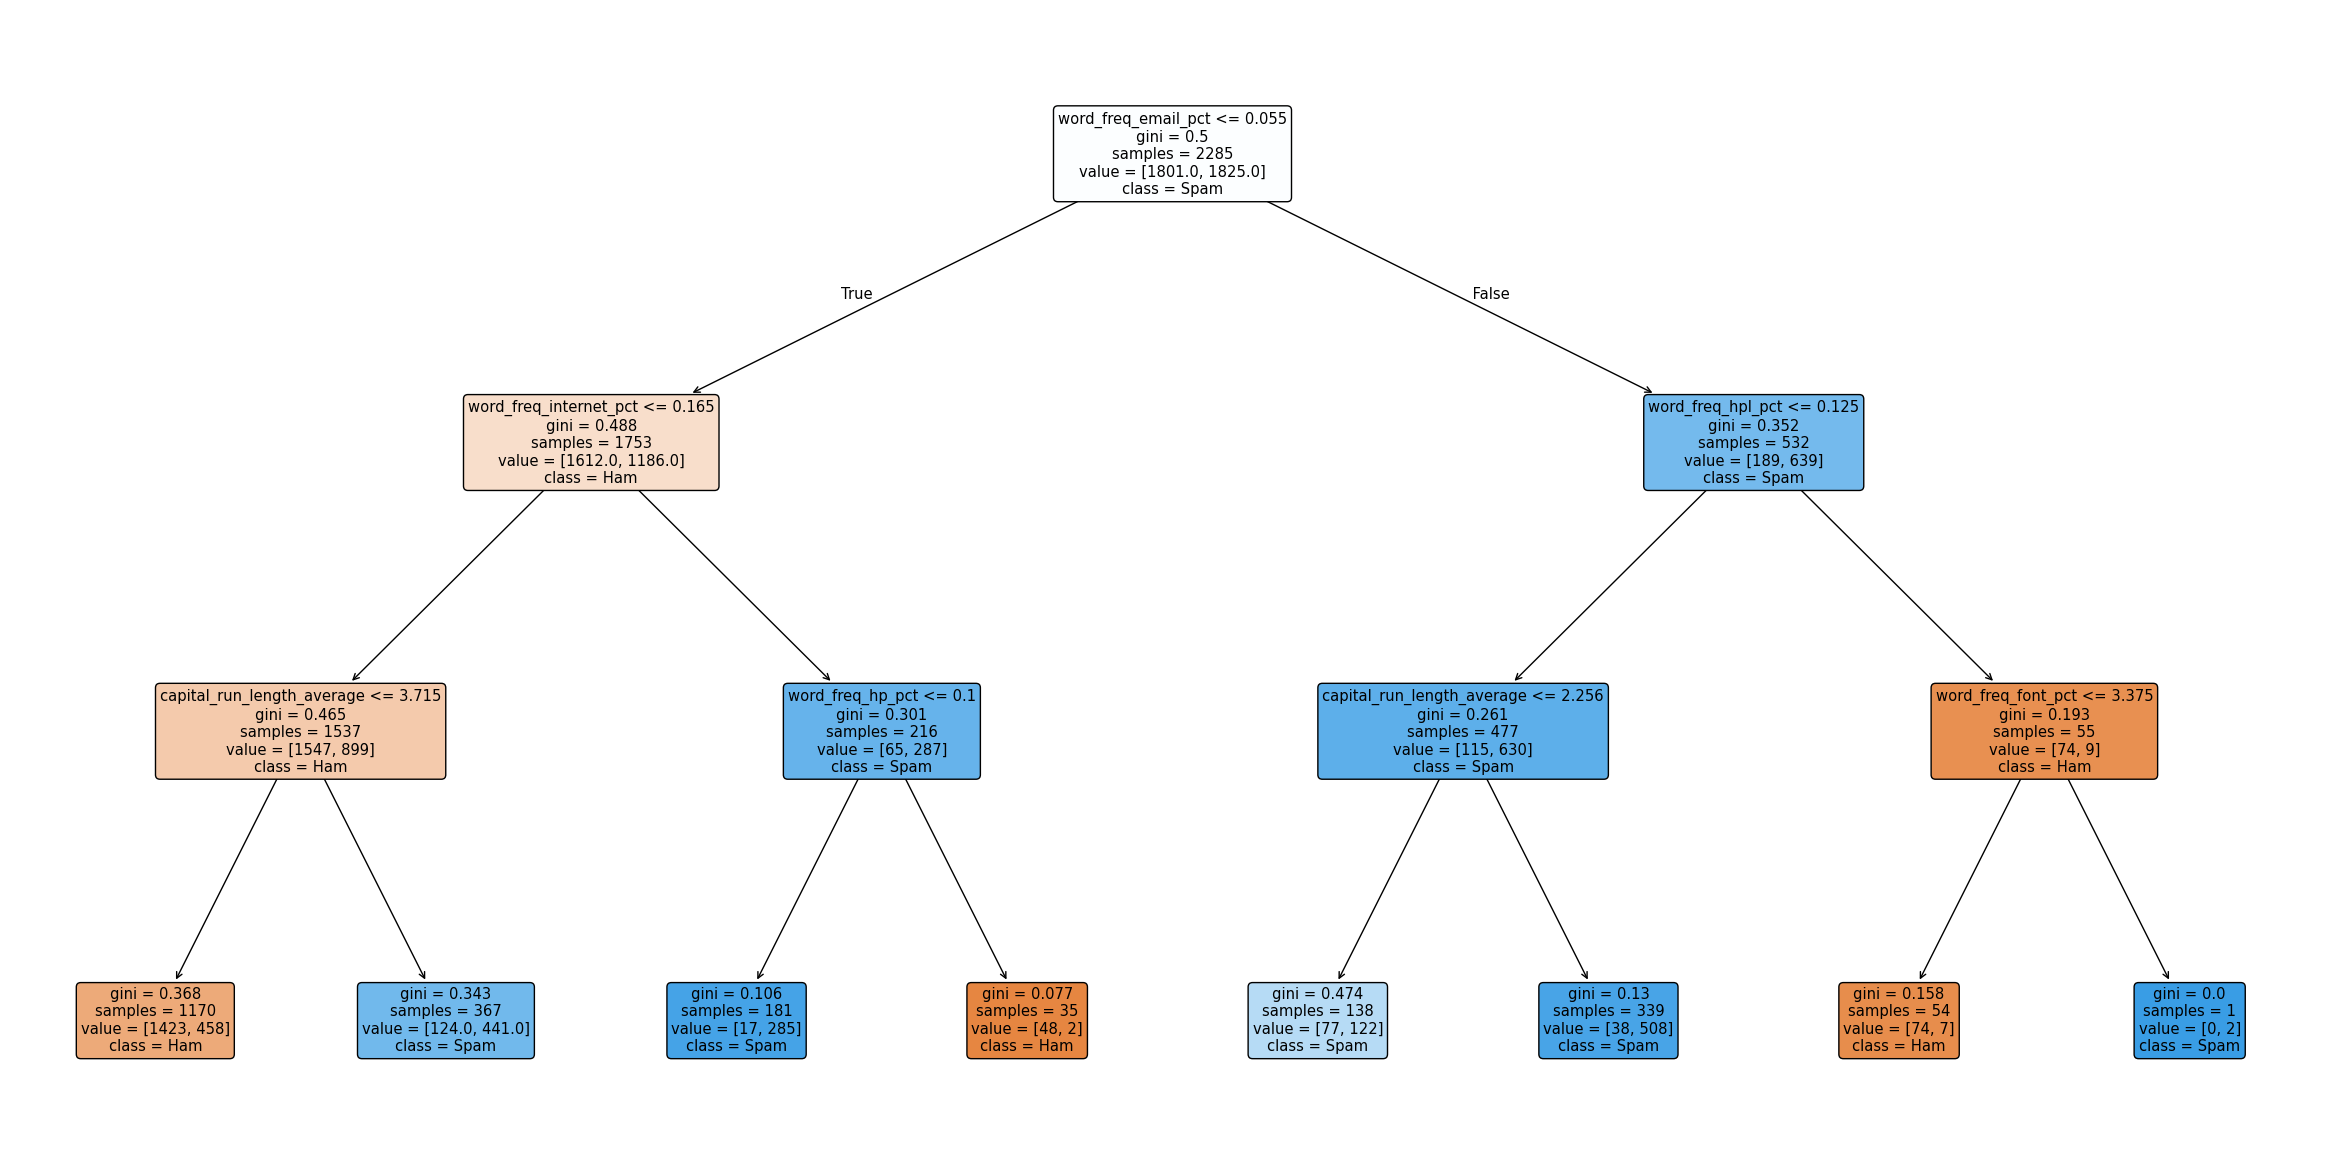

In [59]:
forest_Estimator_Visual = class_utils.Create_RandomForest_Model(3, 100, model_Data_X, model_Data_Y).estimators_[0]       #Currently using the first tree for demonstration and testing.

plt.figure(figsize=(30,15))
plot_tree(forest_Estimator_Visual, feature_names=data_NoClass.columns, class_names=['Ham', 'Spam'], filled=True, rounded=True)
plt.show()

**Feature importances**

In [60]:
forest_Model_Importances = class_utils.Create_RandomForest_Model(20, 100, model_Data_X, model_Data_Y)
forest_Feature_Importances = class_utils.Get_RandomForest_Importances(forest_Model_Importances, data_NoClass.columns)

print(forest_Feature_Importances)
#print(forest_Feature_Importances['importance'].sum())

                       feature  importance
0            char_freq_%21_pct    0.109148
1            char_freq_%24_pct    0.108018
2   capital_run_length_average    0.068359
3   capital_run_length_longest    0.068189
4         word_freq_remove_pct    0.065571
5           word_freq_free_pct    0.054611
6           word_freq_your_pct    0.047638
7             word_freq_hp_pct    0.047481
8     capital_run_length_total    0.043586
9         word_freq_george_pct    0.033559
10           word_freq_you_pct    0.029200
11           word_freq_hpl_pct    0.028755
12         word_freq_money_pct    0.028075
13           word_freq_our_pct    0.026665
14           word_freq_edu_pct    0.025781
15      word_freq_business_pct    0.017600
16           word_freq_000_pct    0.016987
17           char_freq_%28_pct    0.011485
18          word_freq_1999_pct    0.011371
19          word_freq_will_pct    0.011057
20            word_freq_re_pct    0.010764
21      word_freq_internet_pct    0.010506
22       wo

**Summary**
- Most important features included:
    - Character frquencies involve '$' and '!'
    - Capitalisation
    - Promotional terms such as 'remove', 'free', and 'money'.
- Findings suggest spam emails often exhibit exagerated sentence structure and behaviour such as excessive or abnormal punctuation patterns.
- Several techincal terminologies such as 'hp', 'hpl', and 'edu' are also important features, suggesting legitimate emails likely contain structured workplace or academic terms.
- Overall, findings suggest spam classification can be influenced by:
    - Formatting characteristics
    - Promotional language
    - Context-specific terminiology.

### 4.3 - Univariate Feature Selection

In [61]:
data_ClassOnly = data['is_spam']                                                                                #y value for k-best.

In [62]:
kBest_Feature_Selector = SelectKBest(score_func=f_classif, k=15)                                                #Select top 15.
kBest_Feature_Selector = kBest_Feature_Selector.fit(data_NoClass, data_ClassOnly)

In [63]:
kBest_Feature_Scores = pd.DataFrame({'feature' : data_NoClass.columns, 
                                     'score' : kBest_Feature_Selector.scores_,
                                     'is_statistically_significant' : kBest_Feature_Selector.pvalues_ < 0.05})  #Determine if the feature is statistically significant using a p-value threshold of 0.05.

kBest_feature_Scores = kBest_Feature_Scores.sort_values(by='score', ascending=False).reset_index(drop=True)
print(kBest_feature_Scores)

                       feature       score  is_statistically_significant
0           word_freq_your_pct  791.726012                          True
1            word_freq_000_pct  580.534452                          True
2         word_freq_remove_pct  570.169634                          True
3            char_freq_%24_pct  538.029935                          True
4            word_freq_you_pct  372.273985                          True
5           word_freq_free_pct  342.346240                          True
6       word_freq_business_pct  342.316290                          True
7             word_freq_hp_pct  324.490814                          True
8     capital_run_length_total  304.417709                          True
9            word_freq_our_pct  285.890659                          True
10           char_freq_%21_pct  285.810155                          True
11       word_freq_receive_pct  267.687159                          True
12           word_freq_hpl_pct  263.930408         

**How to interpret**
- Higher ```score``` suggests greater seperation between Spam and Ham emails.
    - Features with a higher score are stronger independent predictors of email classification.
    - Lower scores may still contribute towards classification but exhibit weaker seperation.
- ```is_statistically_significant``` has one of two outputs - True or False.
    - True - Feature demonstrates statistical significance with email classification.
    - False - Insufficient evidence to suggest the feature is related to email classification.
- SelectKBest evaluates independent features, therefore it may fail to capture feature interactions or complex relationships.
    - Findings should be used in tandem with RandomForest feature importances, which can capture interactions between multiple features.

**Comparing Top 15 Random Forest to KBest**

Determining which top 15 features in Random Forest appear within KBest top 15. <br>

| Feature |  RF  | KBest |
|:--------:|:--------:|:--------:|
|  char_freq_%24_pct  |   ✓   |  ✓  |
|  char_freq_%21_pct  |   ✓   |  ✓  |
|  word_freq_remove_pct  |   ✓   |  ✓  |
|  capital_run_length_average  |   ✓   |  ✗  |
|  capital_run_length_longest  |   ✓   |  ✗  |
|  word_freq_free_pct  |   ✓   |  ✓  |
|  word_freq_hp_pct  |   ✓   |  ✓  |
|  word_freq_your_pct  |   ✓   |  ✓  |
|  capital_run_length_total  |   ✓   |  ✓  |
|  word_freq_george_pct  |   ✓   |  ✗  |
|  word_freq_money_pct  |   ✓   |  ✗  |
|  word_freq_hpl_pct  |   ✓   |  ✓  |
|  word_freq_our_pct  |   ✓   |  ✓  |
|  word_freq_you_pct  |   ✓   |  ✗  |
|  word_freq_edu_pct  |   ✓   |  ✗  |

**Summary**
- **56** of **57** features were found to be statistically significant predictors of spam classification.
    - The exception  being ```word_freq_will_pct```.
    - Suggests most features exhibit a statistically significant relationship with email classification, albeit some features have a greater or lesser impact than others.
- Approximately a 60% overlap between top 15 ranked features of both models.
    - Suggests consistency between both methods, which increases confidence that these features have an impactful influence at distinguishing Spam and Ham emails.
- Different models favour certain features.
    - Random Forest model places greater emphasis on capitalisation-related features that may interact with other predictors in email classification tasks.
    - SelectKBest places emphasis on features that independently seperate Spam and Ham classifications, which in this case is context-specific terminology.
    - Both consistently identified punctuation-related features (brackets and explanation marks) and promotional terminology (free) as important predictors.

## 5. **Classification Models**

### 5.1. Training/Testing Set

**Things of note**:
- Models need to be trained, therefore a training and testing set is required.
- Will use a default split of **80**/**20**.
- A balanced dataset will be used to mitigate bias.
- Stratify is applied to maintain balance during the split.
- Only a single train/test set will be used to reduce bias from comparing models that use different data subsets.
- A 5-fold cross validation will be used to evaluate the accuracy of trained models.
- An average will be taken from the cross validation.
- Other evaluation methods will be applied where applicable including precision and recall using confusion matrices.

In [64]:
x_Train, x_Test, y_Train, y_Test = train_test_split(model_Data_X, model_Data_Y, test_size=0.2, stratify=model_Data_Y, random_state=1)

**k-Fold Cross Validation**

In [65]:
#Split the training set into 5-fold.
kFold_Cross_Validator = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)                                           

### 5.2 - Logistic Regression

In [66]:
#Pipeline conjoin the scaler to the model.
#Used to prevent data leakage caused by standardising the data. K-fold cross validation in particular, where each k-fold may be influenced by another.
model_Logistic_Regression = Pipeline([
    ("scaler", StandardScaler()),                                     #Capitalisation has extreme values that surpass other features, therefore standardisation is used to minimise dominant features caused by large values.
    ("model", LogisticRegression(max_iter=3000, random_state=1))
])

model_Logistic_Regression = model_Logistic_Regression.fit(x_Train, y_Train)

**Which classification does the feature have a greater influence on?**

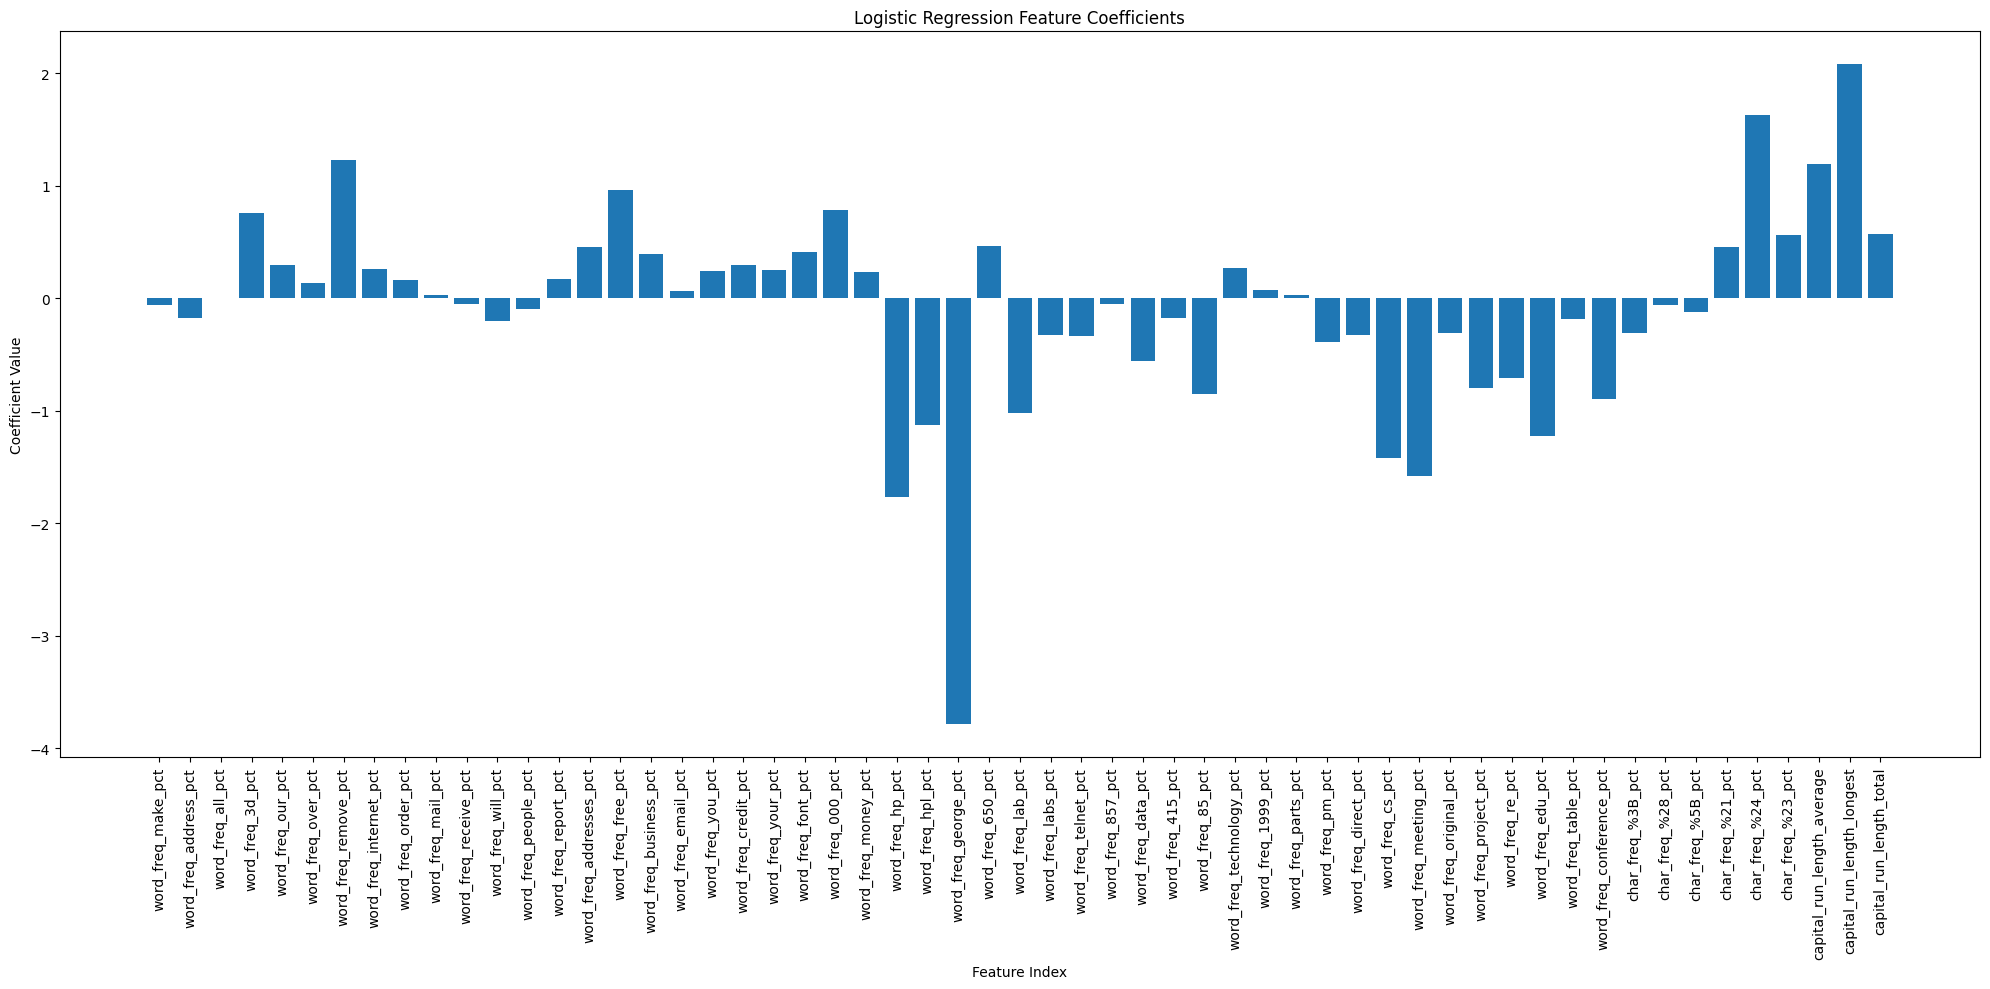

In [67]:
feature_Names = x_Train.columns
logReg_coefficients = model_Logistic_Regression.named_steps["model"].coef_[0]

plt.figure(figsize=(20,10))

plt.bar(feature_Names, logReg_coefficients)
plt.title("Logistic Regression Feature Coefficients")
plt.xticks(rotation=90)
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.tight_layout()
plt.show()

**How to interpret**:
- Positive coefficients indicate features associated with Spam emails.
- Negative coefficients indicate features associated with Ham emails
- Magnitude of coefficients reflect the contribution the feature has towards the corresponding classification.

**Summary**:
- Industry context terminology has a greater influence on ham emails.
    - Technical jargon such as '*hpl*' and '*hp*' as well as identifiers ('*george*') may serve as strong predictors for ham email.
- Features related to sentence structure such as capitalisation and punctuation have a greater influence on spam emails.

#### 5.2.1 - Evaluating Logistic Regression

**K-Fold Cross Validation**

In [68]:
logReg_kFold = eval_utils.Evaluate_kFold_Scores(kFold_Cross_Validator, model_Logistic_Regression, x_Train, y_Train)                  

#print(logReg_kFold_Scores)

#List out the scores using print.
eval_utils.Describe_kFold_Scores(logReg_kFold)                                       

Score of Split 1: 0.9086206896551724
Score of Split 2: 0.9189655172413793
Score of Split 3: 0.9362068965517242
Score of Split 4: 0.9344827586206896
Score of Split 5: 0.9258620689655173

Average Score per K-fold: 0.9248275862068965
Standard Deviation of Scores: 0.010205964542723281


**Summary**:
- μ = ~**92.48%**
- σ = ~**1.02%**
- High accuracy with low variation between folds.
- Suggests model is able to produce consistent results when trained with different subsets of data.
- Indicates that the model is representive of the dataset rather than dependent of a specific partition of training data.

**Predict using the Logistic Regression model.**

In [69]:
logReg_Predict = model_Logistic_Regression.predict(x_Test)

**Accuracy Score**

In [70]:
eval_utils.Evaluate_Accuracy_Score(y_Test, logReg_Predict)

Accuracy Score: 0.9201101928374655


**F1-Score**

In [71]:
eval_utils.Evaluate_F1_Score(y_Test, logReg_Predict, isSpam_labels)

F1 Score (Ham): 0.9194444444444444
F1 Score (Spam): 0.9207650273224044


**Confusion Matrix**

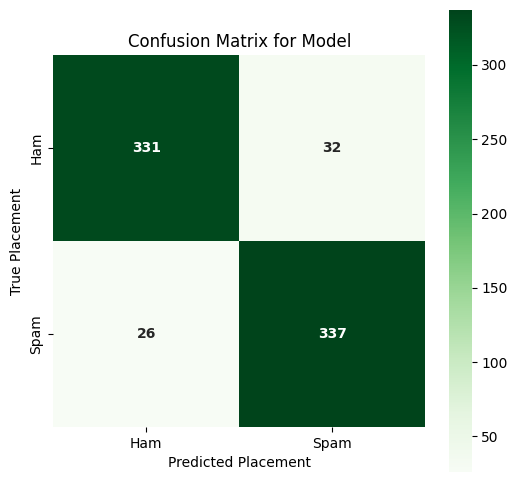

In [72]:
eval_utils.Evaluate_Confusion(y_Test, logReg_Predict, isSpam_labels)

**Summary**:
- Accuracy: **92.01%**
    - **0.47%** difference between K-Fold mean accuracy.
    - Suggests stable performance, therefore insuffient evidence to suggest substantial overfitting or underfitting.
    - Model appears to generalise effectively to unseen data.
- F1-Score (Ham): **91.94%**
- F1-Score (Spam): **92.08%**
    - Model performs consistently across both classes, suggesting it doesn't favour one classification over the other.
- Relatively balanced between false positives and false negatives.
    - Model shows no substantial classification bias towards either class.
    - Model is able to successfully indentify Spam and Ham emails with similar effectiveness.

### 5.3 - Random Forest

In [73]:
model_Random_Forest = class_utils.Create_RandomForest_Model(20, 100, x_Train, y_Train)

#### 5.3.1 - Evaluating Random Forest

**K-Fold Cross Validation**

In [74]:
ranFor_kFold = eval_utils.Evaluate_kFold_Scores(kFold_Cross_Validator, model_Random_Forest, x_Train, y_Train)

eval_utils.Describe_kFold_Scores(ranFor_kFold)

Score of Split 1: 0.9551724137931035
Score of Split 2: 0.9379310344827586
Score of Split 3: 0.9534482758620689
Score of Split 4: 0.9517241379310345
Score of Split 5: 0.9293103448275862

Average Score per K-fold: 0.9455172413793104
Standard Deviation of Scores: 0.010147544116939416


**Predict using Random Forest Model**

In [75]:
ranFor_Predict = model_Random_Forest.predict(x_Test)

**Accuracy Score**

In [76]:
eval_utils.Evaluate_Accuracy_Score(y_Test, ranFor_Predict)

Accuracy Score: 0.953168044077135


**F1-Score**

In [77]:
eval_utils.Evaluate_F1_Score(y_Test, ranFor_Predict, isSpam_labels)

F1 Score (Ham): 0.9534246575342465
F1 Score (Spam): 0.9529085872576177


**Confusion Matrix**

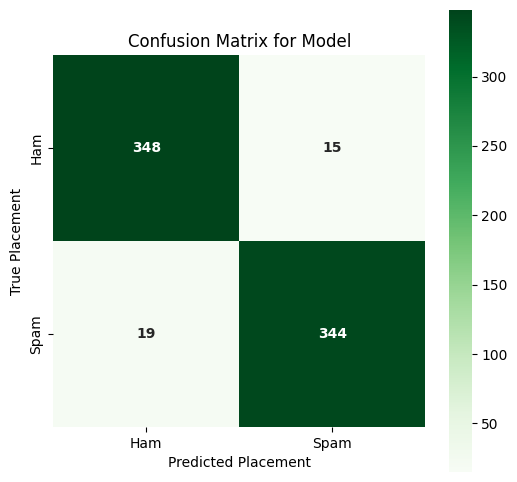

In [78]:
eval_utils.Evaluate_Confusion(y_Test, ranFor_Predict, isSpam_labels)